In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/2014-15_To_2016-17_School-_Level_NYC_Regents_Report_For_All_Variables.csv',index_col=0)

In [95]:
df.sample(10)

,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
School DBN,,,,,,,,,,,,,,
17K340,I.S. 340,Junior High-Intermediate-Middle,Living Environment,2016,1,NaN,s,s,s,s,s,s,na,NaN
22K207,P.S. 207 Elizabeth G. Leary,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,6,37.5,na,NaN
84X393,University Prep Charter High School,High school,Global History and Geography,2016,35,73.5,6,17.1,29,82.9,11,31.4,na,NaN
07X427,Community School for Social Justice,High school,English,2015,47,69.2,10,21.3,37,78.7,6,12.8,17,36.2
31R460,Susan E. Wagner High School,High school,Common Core Geometry,2015,308,61.6,170,55.2,138,44.8,22,7.1,97,31.5
13K499,ACORN Community High School,High school,English,2015,87,62.5,44,50.6,43,49.4,9,10.3,22,25.3
05M285,Harlem Renaissance High School,High school,Living Environment,2017,47,61.2,26,55.3,21,44.7,2,4.3,na,NaN
84M707,John V. Lindsay Wildcat Academy Charter School,High school,Global History and Geography,2017,1,NaN,s,s,s,s,s,s,na,NaN
84K704,Explore Charter School,K-8,Common Core Algebra,2015,5,NaN,s,s,s,s,s,s,na,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 212331 entries, 01M034 to 84X717
Data columns (total 14 columns):
 #   Column                       Non-Null Count   Dtype 
---  ------                       --------------   ----- 
 0   School Name                  212331 non-null  object
 1   School Level                 212331 non-null  object
 2   Regents Exam                 212321 non-null  object
 3   Year                         212331 non-null  int64 
 4   Total Tested                 212331 non-null  int64 
 5   Mean Score                   212331 non-null  object
 6   Number Scoring Below 65      212331 non-null  object
 7   Percent Scoring Below 65     212331 non-null  object
 8   Number Scoring 65 or Above   212331 non-null  object
 9   Percent Scoring 65 or Above  212331 non-null  object
 10  Number Scoring 80 or Above   212331 non-null  object
 11  Percent Scoring 80 or Above  212331 non-null  object
 12  Number Scoring CR            212331 non-null  object
 13  Percent Scorin

In [ ]:
df['Mean Score'].head(10)

,Mean Score
School DBN,
01M034,s
01M034,77.9
01M034,74
01M140,s
01M140,s
01M140,67.4
01M140,72.6
01M140,64.4
01M184,78.4


Here, I decided that I wanted to base my comparison on the media, so a cleaning task was necessary.

In [ ]:
df['Mean Score'] = df['Mean Score'].replace('s', np.nan)
df['Mean Score'] = pd.to_numeric(df['Mean Score'], errors='coerce')

In [ ]:
print(df['Mean Score'].dtype)
print(df['Mean Score'].head(10))

float64
School DBN
01M034     NaN
01M034    77.9
01M034    74.0
01M140     NaN
01M140     NaN
01M140    67.4
01M140    72.6
01M140    64.4
01M184    78.4
01M184    79.0
Name: Mean Score, dtype: float64


Following this, I was curious to see the highest and lowest scores and which schools had them.

In [ ]:
Max_mean_score = df['Mean Score'].max()
print(Max_mean_score)

98.7


In [ ]:
Min_mean_score = df['Mean Score'].min()
print(Min_mean_score)

15.0


In [ ]:
max_score = df['Mean Score'].max()
max_rows = df[df['Mean Score'] == max_score]
max_rows[['School Name', 'Regents Exam', 'Year', 'Mean Score']]

,School Name,Regents Exam,Year,Mean Score
School DBN,,,,
10X696,High School of American Studies at Lehman College,U.S. History and Government,2017,98.7


In [ ]:
min_score = df['Mean Score'].min()
min_rows = df[df['Mean Score'] == min_score]
min_rows[['School Name', 'Regents Exam', 'Year', 'Mean Score']]

,School Name,Regents Exam,Year,Mean Score
School DBN,,,,
16K498,Brooklyn High School for Law and Technology,Common Core English,2015,15.0


Here, I just wanted to take a closer look at the performance of these specific schools over the years and across Regents exams.

In [ ]:
school_df = df[df['School Name'] == 'Brooklyn High School for Law and Technology']
school_df

,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
School DBN,,,,,,,,,,,,,,
16K498,Brooklyn High School for Law and Technology,High school,Algebra2/Trigonometry,2015,46,56.1,32,69.6,14,30.4,0,0,0,0
16K498,Brooklyn High School for Law and Technology,High school,Algebra2/Trigonometry,2016,49,68.5,19,38.8,30,61.2,12,24.5,12,24.5
16K498,Brooklyn High School for Law and Technology,High school,Algebra2/Trigonometry,2017,6,40.8,6,100,0,0,0,0,0,0
16K498,Brooklyn High School for Law and Technology,High school,Common Core Algebra,2015,247,57.8,156,63.2,91,36.8,0,0,33,13.4
16K498,Brooklyn High School for Law and Technology,High school,Common Core Algebra,2016,196,63.2,85,43.4,111,56.6,7,3.6,62,31.6
16K498,Brooklyn High School for Law and Technology,High school,Common Core Algebra,2017,213,62.3,107,50.2,106,49.8,12,5.6,66,31
16K498,Brooklyn High School for Law and Technology,High school,Common Core Algebra2,2016,39,58.2,28,71.8,11,28.2,0,0,11,28.2
16K498,Brooklyn High School for Law and Technology,High school,Common Core Algebra2,2017,26,58.0,16,61.5,10,38.5,0,0,10,38.5
16K498,Brooklyn High School for Law and Technology,High school,Common Core English,2015,129,19.8,121,93.8,8,6.2,4,3.1,5,3.9


In [ ]:
school_df = df[df['School Name'] == 'High School of American Studies at Lehman College']
school_df

,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
School DBN,,,,,,,,,,,,,,
10X696,High School of American Studies at Lehman College,High school,Algebra2/Trigonometry,2015,113,85.4,8,7.1,105,92.9,86,76.1,86,76.1
10X696,High School of American Studies at Lehman College,High school,Algebra2/Trigonometry,2016,78,84.9,5,6.4,73,93.6,57,73.1,57,73.1
10X696,High School of American Studies at Lehman College,High school,Algebra2/Trigonometry,2017,21,93.7,0,0,21,100,21,100,21,100
10X696,High School of American Studies at Lehman College,High school,Common Core Algebra,2015,35,77.0,0,0,35,100,7,20,35,100
10X696,High School of American Studies at Lehman College,High school,Common Core Algebra,2016,84,85.3,1,1.2,83,98.8,75,89.3,83,98.8
10X696,High School of American Studies at Lehman College,High school,Common Core Algebra,2017,59,86.3,0,0,59,100,59,100,59,100
10X696,High School of American Studies at Lehman College,High school,Common Core Algebra2,2016,19,79.8,1,5.3,18,94.7,13,68.4,18,94.7
10X696,High School of American Studies at Lehman College,High school,Common Core Algebra2,2017,94,84.4,0,0,94,100,84,89.4,94,100
10X696,High School of American Studies at Lehman College,High school,Common Core English,2016,77,95.2,0,0,77,100,76,98.7,76,98.7


In [ ]:
df.columns

Index(['School Name', 'School Level', 'Regents Exam', 'Year', 'Total Tested',
       'Mean Score', 'Number Scoring Below 65', 'Percent Scoring Below 65',
       'Number Scoring 65 or Above', 'Percent Scoring 65 or Above',
       'Number Scoring 80 or Above', 'Percent Scoring 80 or Above',
       'Number Scoring CR', 'Percent Scoring CR'],
      dtype='object')

In [108]:
df['Regents Exam'].nunique()

14

In [109]:
df['Regents Exam'].value_counts().index.tolist()

['Common Core Algebra',
 'Living Environment',
 'U.S. History and Government',
 'Common Core English',
 'Global History and Geography',
 'Physical Settings/Earth Science',
 'Common Core Geometry',
 'Physical Settings/Chemistry',
 'English',
 'Integrated Algebra',
 'Algebra2/Trigonometry',
 'Geometry',
 'Common Core Algebra2',
 'Physical Settings/Physics']

After selecting Lehman School as the school to analyze and compare within the dataset, I wanted to understand why there were multiple rows for the same school, Regents exam, and year, and whether another field further subdivided the data or if the rows were duplicates.

In [ ]:
df[
    (df['School Name'] == 'High School of American Studies at Lehman College') &
    (df['Year'] == 2017) &
    (df['Regents Exam'] == 'U.S. History and Government')
].to_string()

'                                                  School Name School Level                 Regents Exam  Year  Total Tested  Mean Score Number Scoring Below 65 Percent Scoring Below 65 Number Scoring 65 or Above Percent Scoring 65 or Above Number Scoring 80 or Above Percent Scoring 80 or Above Number Scoring CR Percent Scoring CR\nSchool DBN                                                                                                                                                                                                                                                                                                                                 \n10X696      High School of American Studies at Lehman College  High school  U.S. History and Government  2017            91        98.3                       0                        0                         91                         100                         91                         100                na                 na\n

In [ ]:
school_year_exam = df[
    (df['School Name'] == 'High School of American Studies at Lehman College') &
    (df['Year'] == 2017) &
    (df['Regents Exam'] == 'U.S. History and Government')
]

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print(school_year_exam.to_string())

                                                  School Name School Level                 Regents Exam  Year  Total Tested  Mean Score Number Scoring Below 65 Percent Scoring Below 65 Number Scoring 65 or Above Percent Scoring 65 or Above Number Scoring 80 or Above Percent Scoring 80 or Above Number Scoring CR Percent Scoring CR
School DBN                                                                                                                                                                                                                                                                                                                                 
10X696      High School of American Studies at Lehman College  High school  U.S. History and Government  2017            91        98.3                       0                        0                         91                         100                         91                         100                na                 na
10X6

Since both schools identified in the analysis of the minimum and maximum scores were at the high school level, I wanted to understand which school levels were represented across the entire dataset to make the comparison more objective.

In [ ]:
df['School Level'].value_counts().index.tolist()

['High school',
 'Secondary School',
 'Junior High-Intermediate-Middle',
 'K-12 all grades',
 'K-8',
 'Elementary']

Next, I cleaned the columns I intended to use in the analysis. With the help of AI, I learned about the 'for' function, which simplifies the code by working as a loop.

In [96]:
numeric_cols = [
    'Mean Score',
    'Number Scoring 65 or Above',
    'Percent Scoring 65 or Above'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col].replace('s', np.nan), errors='coerce')

In [97]:
print(df[numeric_cols].dtypes)
print(df[numeric_cols].head())

Mean Score                     float64
Number Scoring 65 or Above     float64
Percent Scoring 65 or Above    float64
dtype: object
            Mean Score  Number Scoring 65 or Above  \
School DBN                                           
01M034             NaN                         NaN   
01M034            77.9                        15.0   
01M034            74.0                         8.0   
01M140             NaN                         NaN   
01M140             NaN                         NaN   

            Percent Scoring 65 or Above  
School DBN                               
01M034                              NaN  
01M034                             93.8  
01M034                             88.9  
01M140                              NaN  
01M140                              NaN  


Here, I filtered and explored the dataset to focus on the school I selected for comparison and decided to narrow the scope of the analysis to a specific Regents exam. In my opinion, this would make the analysis more objective.

In [98]:
school_name = 'High School of American Studies at Lehman College'
school_df = df[df['School Name'] == school_name].copy()
print(school_df.shape)

(377, 14)


In [99]:
print("Years available:", sorted(school_df['Year'].unique()))
print("Number of exams:", school_df['Regents Exam'].nunique())
print("Exam names:", school_df['Regents Exam'].unique())

Years available: [np.int64(2015), np.int64(2016), np.int64(2017)]
Number of exams: 13
Exam names: ['Algebra2/Trigonometry' 'Common Core Algebra' 'Common Core Algebra2'
 'Common Core English' 'Common Core Geometry' 'English' 'Geometry'
 'Global History and Geography' 'Integrated Algebra' 'Living Environment'
 'Physical Settings/Chemistry' 'Physical Settings/Physics'
 'U.S. History and Government']


In [100]:
exam_name = 'U.S. History and Government'

school_exam = school_df[school_df['Regents Exam'] == exam_name].copy()

print(school_exam.shape)
print(school_exam[['Year', 'Mean Score', 'Percent Scoring 65 or Above']].head(10))

(36, 14)
            Year  Mean Score  Percent Scoring 65 or Above
School DBN                                               
10X696      2015        97.4                        100.0
10X696      2016        97.6                        100.0
10X696      2017        98.3                        100.0
10X696      2015         NaN                          NaN
10X696      2015         NaN                          NaN
10X696      2016         NaN                          NaN
10X696      2016         NaN                          NaN
10X696      2017         NaN                          NaN
10X696      2017         NaN                          NaN
10X696      2015        97.5                        100.0


Since there are multiple rows corresponding to the same school, year, and Regents exam, the following aggregates the mean score and the percentage of students scoring 65 or above for each year.

In [104]:
school_name = 'High School of American Studies at Lehman College'
exam_name = 'U.S. History and Government'

school_exam = df[
    (df['School Name'] == school_name) &
    (df['Regents Exam'] == exam_name)
].copy()

school_yearly = school_exam.groupby('Year').agg({
    'Mean Score': 'median',
    'Percent Scoring 65 or Above': 'median'
}).reset_index()

print(school_yearly)

   Year  Mean Score  Percent Scoring 65 or Above
0  2015       97.25                        100.0
1  2016       97.55                        100.0
2  2017       98.35                        100.0


Here, I created the comparison group, which will serve as the baseline for comparison with the school I selected.

In [105]:
all_exam = df[df['Regents Exam'] == exam_name].copy()

all_yearly = all_exam.groupby('Year').agg({
    'Mean Score': 'median',
    'Percent Scoring 65 or Above': 'median'
}).reset_index()

print(all_yearly)

   Year  Mean Score  Percent Scoring 65 or Above
0  2015        71.5                         74.7
1  2016        70.3                         71.6
2  2017        70.1                         69.5


The comparison of the three-year performance of the High School of American Studies at Lehman College against all other schools taking the same Regents exam.

In [106]:
comparison = school_yearly.merge(
    all_yearly,
    on='Year',
    how='inner',
    suffixes=('_school', '_all')
)

print(comparison)

   Year  Mean Score_school  Percent Scoring 65 or Above_school  \
0  2015              97.25                               100.0   
1  2016              97.55                               100.0   
2  2017              98.35                               100.0   

   Mean Score_all  Percent Scoring 65 or Above_all  
0            71.5                             74.7  
1            70.3                             71.6  
2            70.1                             69.5  


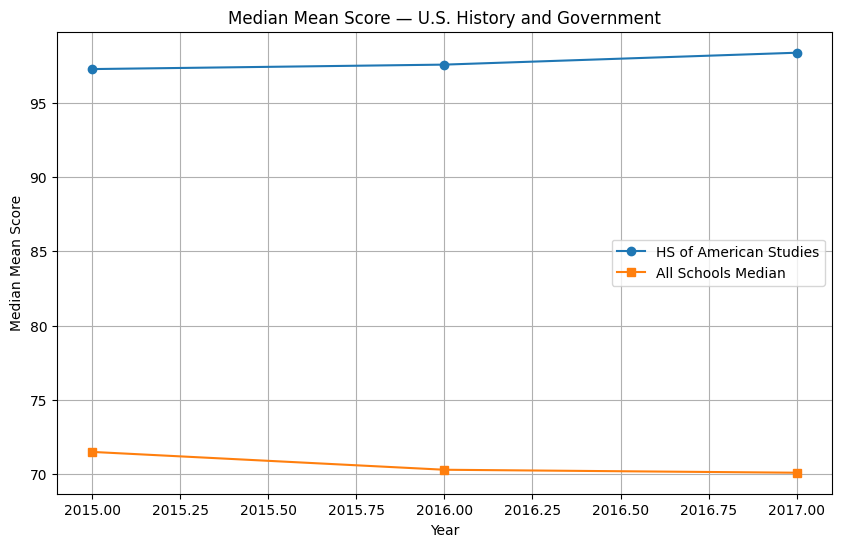

In [107]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(comparison['Year'], comparison['Mean Score_school'], marker='o', label='HS of American Studies')
plt.plot(comparison['Year'], comparison['Mean Score_all'], marker='s', label='All Schools Median')
plt.title('Median Mean Score — U.S. History and Government')
plt.xlabel('Year')
plt.ylabel('Median Mean Score')
plt.legend()
plt.grid(True)
plt.show()

Conclusion:
High School of American Studies achieved near-perfect results on the U.S. History and Government exam from 2015 to 2017, with median scores above 97 and 100% of students scoring 65 or above. Compared to the dataset-wide median, the school stands out as a top performer. These findings highlight its consistent academic strength in this subject.